# Notebook 2 — Génération par IA Générative (CTGAN) + XGBoost-B-GHM

**Credit Scoring PME via ERP Wanzo — République Démocratique du Congo**

## Approche
Génération de données synthétiques via **CTGAN** (Conditional Tabular GAN — Xu et al. 2019) :
- Un GAN conditionnel entraîné sur les données paramétriques de référence
- Le générateur apprend la **distribution jointe** de toutes les variables simultanément
- Avantage : capture les corrélations inter-variables automatiquement
- Le modèle XGBoost est ensuite entraîné sur les données CTGAN

## Comparaison avec le Notebook 1
| Aspect | Classique (NB1) | CTGAN (NB2) |
|--------|----------------|-------------|
| Distributions | Indépendantes, calibrées par expert | Jointes, apprises par réseau de neurones |
| Corrélations | Introduites via le logit cible | Capturées automatiquement |
| Contrôle | Total (chaque paramètre visible) | Boîte noire (réseau génératif) |
| Scalabilité | Nécessite expertise par variable | S'adapte à toute structure |

## Pipeline
1. Chargement des données seed (paramétriques)
2. Entraînement CTGAN sur les données seed
3. Génération de N=5000 échantillons synthétiques
4. Validation statistique des données CTGAN
5. Feature Engineering identique
6. Sélection Boruta + XGBoost-B-GHM
7. **Visualisation des arbres** pour l'explicabilité
8. Comparaison avec le Notebook 1

---
**Références** : Xu et al. (2019) — CTGAN, NeurIPS ; Xia et al. (2024) — XGBoost-B-GHM

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib Boruta shap graphviz ctgan --quiet

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, average_precision_score, brier_score_loss
)
import xgboost as xgb
import joblib
from boruta import BorutaPy
from ctgan import CTGAN

print("✅ Bibliothèques importées (incl. CTGAN)")

✅ Bibliothèques importées (incl. CTGAN)


## 1. Chargement des données seed (paramétriques)

On charge les données générées par le Notebook 1 (génération classique paramétrique).
Ces données servent de **seed** pour entraîner le CTGAN.

In [ ]:
# Charger les données seed du Notebook 1
# Si le fichier n'existe pas, on régénère les données paramétriques
import os

if os.path.exists('data/data_classique_seed.csv'):
    data_seed = pd.read_csv('data/data_classique_seed.csv')
    print(f"✅ Données seed chargées : {data_seed.shape}")
else:
    print("⚠️ Fichier data/data_classique_seed.csv non trouvé.")
    print("   Exécutez d'abord le Notebook 1 (01_xgboost_generation_classique.ipynb)")
    print("   Génération paramétrique de secours...")
    
    np.random.seed(42)
    N = 5000
    secteurs = ['Commerce', 'Agriculture', 'Manufacture', 'Services', 'Construction', 'Transport', 'TIC', 'Mines']
    secteur = np.random.choice(secteurs, N, p=[0.30, 0.20, 0.15, 0.15, 0.08, 0.05, 0.04, 0.03])
    tailles = ['Micro', 'Petite', 'Moyenne']
    taille = np.random.choice(tailles, N, p=[0.50, 0.35, 0.15])
    villes = ['Kinshasa', 'Lubumbashi', 'Goma', 'Bukavu', 'Mbuji-Mayi', 'Kisangani', 'Matadi', 'Kolwezi']
    localisation = np.random.choice(villes, N, p=[0.30, 0.20, 0.12, 0.10, 0.08, 0.08, 0.07, 0.05])
    anciennete_annees = np.random.exponential(5, N).clip(0.5, 30).round(1)
    nb_employes = np.random.lognormal(mean=2, sigma=0.8, size=N).clip(1, 200).astype(int)
    chiffre_affaires = np.random.lognormal(mean=16.5, sigma=1.2, size=N).clip(5e5, 5e8).round(0)
    nb_transactions_mois = np.random.poisson(lam=80, size=N).clip(5, 500)
    montant_moyen_transaction = (chiffre_affaires / (nb_transactions_mois * 12)).round(0)
    payment_mix = np.random.dirichlet([24, 5.1, 0.9], N)
    pct_cash = payment_mix[:, 0].round(4)
    pct_mobile_money = payment_mix[:, 1].round(4)
    pct_banque = payment_mix[:, 2].round(4)
    diversification_paiement = (1 - (pct_cash**2 + pct_mobile_money**2 + pct_banque**2)).round(4)
    pct_transactions_usd = np.random.beta(3, 3, N).round(4)
    charges_exploitation = (chiffre_affaires * np.random.uniform(0.55, 0.92, N)).round(0)
    resultat_net = chiffre_affaires - charges_exploitation
    marge_nette = (resultat_net / chiffre_affaires).round(4)
    solde_caisse_moyen = (chiffre_affaires * np.random.uniform(0.02, 0.15, N)).round(0)

✅ Données seed chargées : (5000, 59)

Taux de défaut seed : 12.8%
Colonnes : 59


,secteur,taille,localisation,anciennete_annees,nb_employes,chiffre_affaires,nb_transactions_mois,montant_moyen_transaction,pct_cash,pct_mobile_money,...,conso_energie_kwh,tendance_energie,conso_eau_m3,trafic_web_mensuel,nb_avis_en_ligne,note_avis_moyenne,regularite_paiement_energie,regularite_paiement_eau,regularite_paiement_loyer,default
0,Agriculture,Micro,Lubumbashi,3.5,3,99000702.0,75,110001.0,0.8428,0.1542,...,845.0,0.0518,23.0,222.0,6,3.0,0.7422,0.7568,0.7192,0
1,TIC,Micro,Lubumbashi,6.9,11,2993911.0,84,2970.0,0.7885,0.2108,...,165.0,-0.1553,5.0,35.0,9,2.9,0.6243,0.8139,0.6147,0
2,Services,Moyenne,Kinshasa,4.1,21,2666216.0,79,2812.0,0.7983,0.1522,...,469.0,-0.0087,66.0,6854.0,12,3.9,0.6671,0.3862,0.8806,0
3,Manufacture,Micro,Goma,0.5,2,3510078.0,79,3703.0,0.7601,0.2350,...,894.0,0.0272,125.0,2613.0,5,3.6,0.9584,0.6258,0.3668,0
4,Commerce,Moyenne,Lubumbashi,1.0,29,17214540.0,86,16681.0,0.6881,0.2860,...,432.0,-0.0876,49.0,71.0,5,3.4,0.2160,0.3516,0.7379,1


## 2. Entraînement du CTGAN (IA Générative)

**CTGAN** (Conditional Tabular GAN) — Xu et al. (2019) :
- Mode-specific normalization pour les variables continues
- Training-by-sampling conditionnel pour gérer les classes déséquilibrées
- Apprend la distribution jointe d'un tableau tabulaire mixte (numérique + catégoriel)

In [3]:
# Variables discrètes (catégorielles + binaires)
discrete_columns = [
    'secteur', 'taille', 'localisation',
    'appartenance_association', 'usage_whatsapp_business', 'default'
]

# Entraînement du CTGAN
print("⏳ Entraînement du CTGAN (300 epochs)...")
print("   Cela peut prendre quelques minutes.\n")

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    generator_lr=2e-4,
    discriminator_lr=2e-4,
    verbose=True
)

ctgan.fit(data_seed, discrete_columns=discrete_columns)
print("\n✅ CTGAN entraîné avec succès")

⏳ Entraînement du CTGAN (300 epochs)...
   Cela peut prendre quelques minutes.



Gen. (-05.76) | Discrim. (+00.12): 100%|██████████| 300/300 [31:37<00:00,  6.32s/it]


✅ CTGAN entraîné avec succès


In [4]:
# Génération de données synthétiques via CTGAN
N_gen = 5000
data_ctgan = ctgan.sample(N_gen)

# Post-traitement : assurer la cohérence des bornes
# (le CTGAN peut générer des valeurs hors des bornes physiques)
data_ctgan['anciennete_annees'] = data_ctgan['anciennete_annees'].clip(0.5, 30)
data_ctgan['nb_employes'] = data_ctgan['nb_employes'].clip(1, 200).astype(int)
data_ctgan['chiffre_affaires'] = data_ctgan['chiffre_affaires'].clip(5e5, 5e8)
data_ctgan['nb_transactions_mois'] = data_ctgan['nb_transactions_mois'].clip(5, 500).astype(int)

# Bornes [0,1] pour les proportions et scores
cols_01 = ['pct_cash', 'pct_mobile_money', 'pct_banque', 'pct_transactions_usd',
           'marge_nette', 'variabilite_ca', 'taux_recouvrement_creances',
           'regularite_paiement_mobile', 'regularite_paiement_fournisseurs',
           'pct_activite_informelle', 'score_reseau_communautaire',
           'pct_clients_recurrents', 'score_reputation_terrain',
           'part_credit_informel', 'exposition_zones_instables',
           'diversification_activites', 'score_debrouillardise',
           'regularite_paiement_energie', 'regularite_paiement_eau',
           'regularite_paiement_loyer']
for col in cols_01:
    if col in data_ctgan.columns:
        data_ctgan[col] = data_ctgan[col].clip(0, 1)

# Bornes positives
cols_pos = ['chiffre_affaires', 'charges_exploitation', 'solde_caisse_moyen',
            'entrees_tresorerie_mois', 'sorties_tresorerie_mois',
            'remboursements_dettes_mois', 'conso_energie_kwh', 'conso_eau_m3',
            'trafic_web_mensuel', 'social_media_abonnes', 'montant_moyen_transaction']
for col in cols_pos:
    if col in data_ctgan.columns:
        data_ctgan[col] = data_ctgan[col].clip(lower=0)

# Binaires
data_ctgan['appartenance_association'] = (data_ctgan['appartenance_association'] > 0.5).astype(int)
data_ctgan['usage_whatsapp_business'] = (data_ctgan['usage_whatsapp_business'] > 0.5).astype(int)
data_ctgan['default'] = (data_ctgan['default'] > 0.5).astype(int)

# Sentiment : [-1, 1]
data_ctgan['social_media_sentiment'] = data_ctgan['social_media_sentiment'].clip(-1, 1)
data_ctgan['note_avis_moyenne'] = data_ctgan['note_avis_moyenne'].clip(1, 5)

print(f"✅ {N_gen} PME générées via CTGAN")
print(f"   Taux de défaut CTGAN : {data_ctgan['default'].mean()*100:.1f}%")
print(f"   (Seed paramétrique : {data_seed['default'].mean()*100:.1f}%)")
data_ctgan.head()

✅ 5000 PME générées via CTGAN
   Taux de défaut CTGAN : 12.0%
   (Seed paramétrique : 12.8%)


,secteur,taille,localisation,anciennete_annees,nb_employes,chiffre_affaires,nb_transactions_mois,montant_moyen_transaction,pct_cash,pct_mobile_money,...,conso_energie_kwh,tendance_energie,conso_eau_m3,trafic_web_mensuel,nb_avis_en_ligne,note_avis_moyenne,regularite_paiement_energie,regularite_paiement_eau,regularite_paiement_loyer,default
0,Manufacture,Micro,Kinshasa,4.893671,79,1.568499e+07,99,8839.925479,0.894540,0.237334,...,270.860053,-0.022932,7.108891,0.000000,13,2.988674,0.907679,0.526685,0.489819,0
1,Construction,Petite,Goma,1.854146,10,1.282792e+07,63,23309.723293,0.900334,0.075419,...,37.539379,-0.071499,29.773171,1595.281812,11,4.660247,0.875275,0.586097,0.661851,0
2,Transport,Petite,Bukavu,4.221015,9,5.000000e+05,75,27053.790585,0.916416,0.192141,...,0.000000,-0.115501,36.189937,22982.823192,4,3.530829,0.823290,0.476835,0.651262,0
3,Commerce,Petite,Matadi,2.103299,6,1.146094e+07,84,11961.610785,0.747610,0.151528,...,81.665915,0.005317,14.196369,2505.416735,8,2.984410,0.674859,0.396493,0.602747,1
4,Manufacture,Micro,Lubumbashi,11.521803,11,1.589380e+07,77,28252.369969,0.864666,0.151993,...,179.620695,0.158476,13.810741,0.000000,11,1.759537,0.942625,0.682298,0.528137,0


## 3. Validation statistique — Comparaison Seed vs CTGAN

Vérification que le CTGAN a bien appris la distribution des données seed.

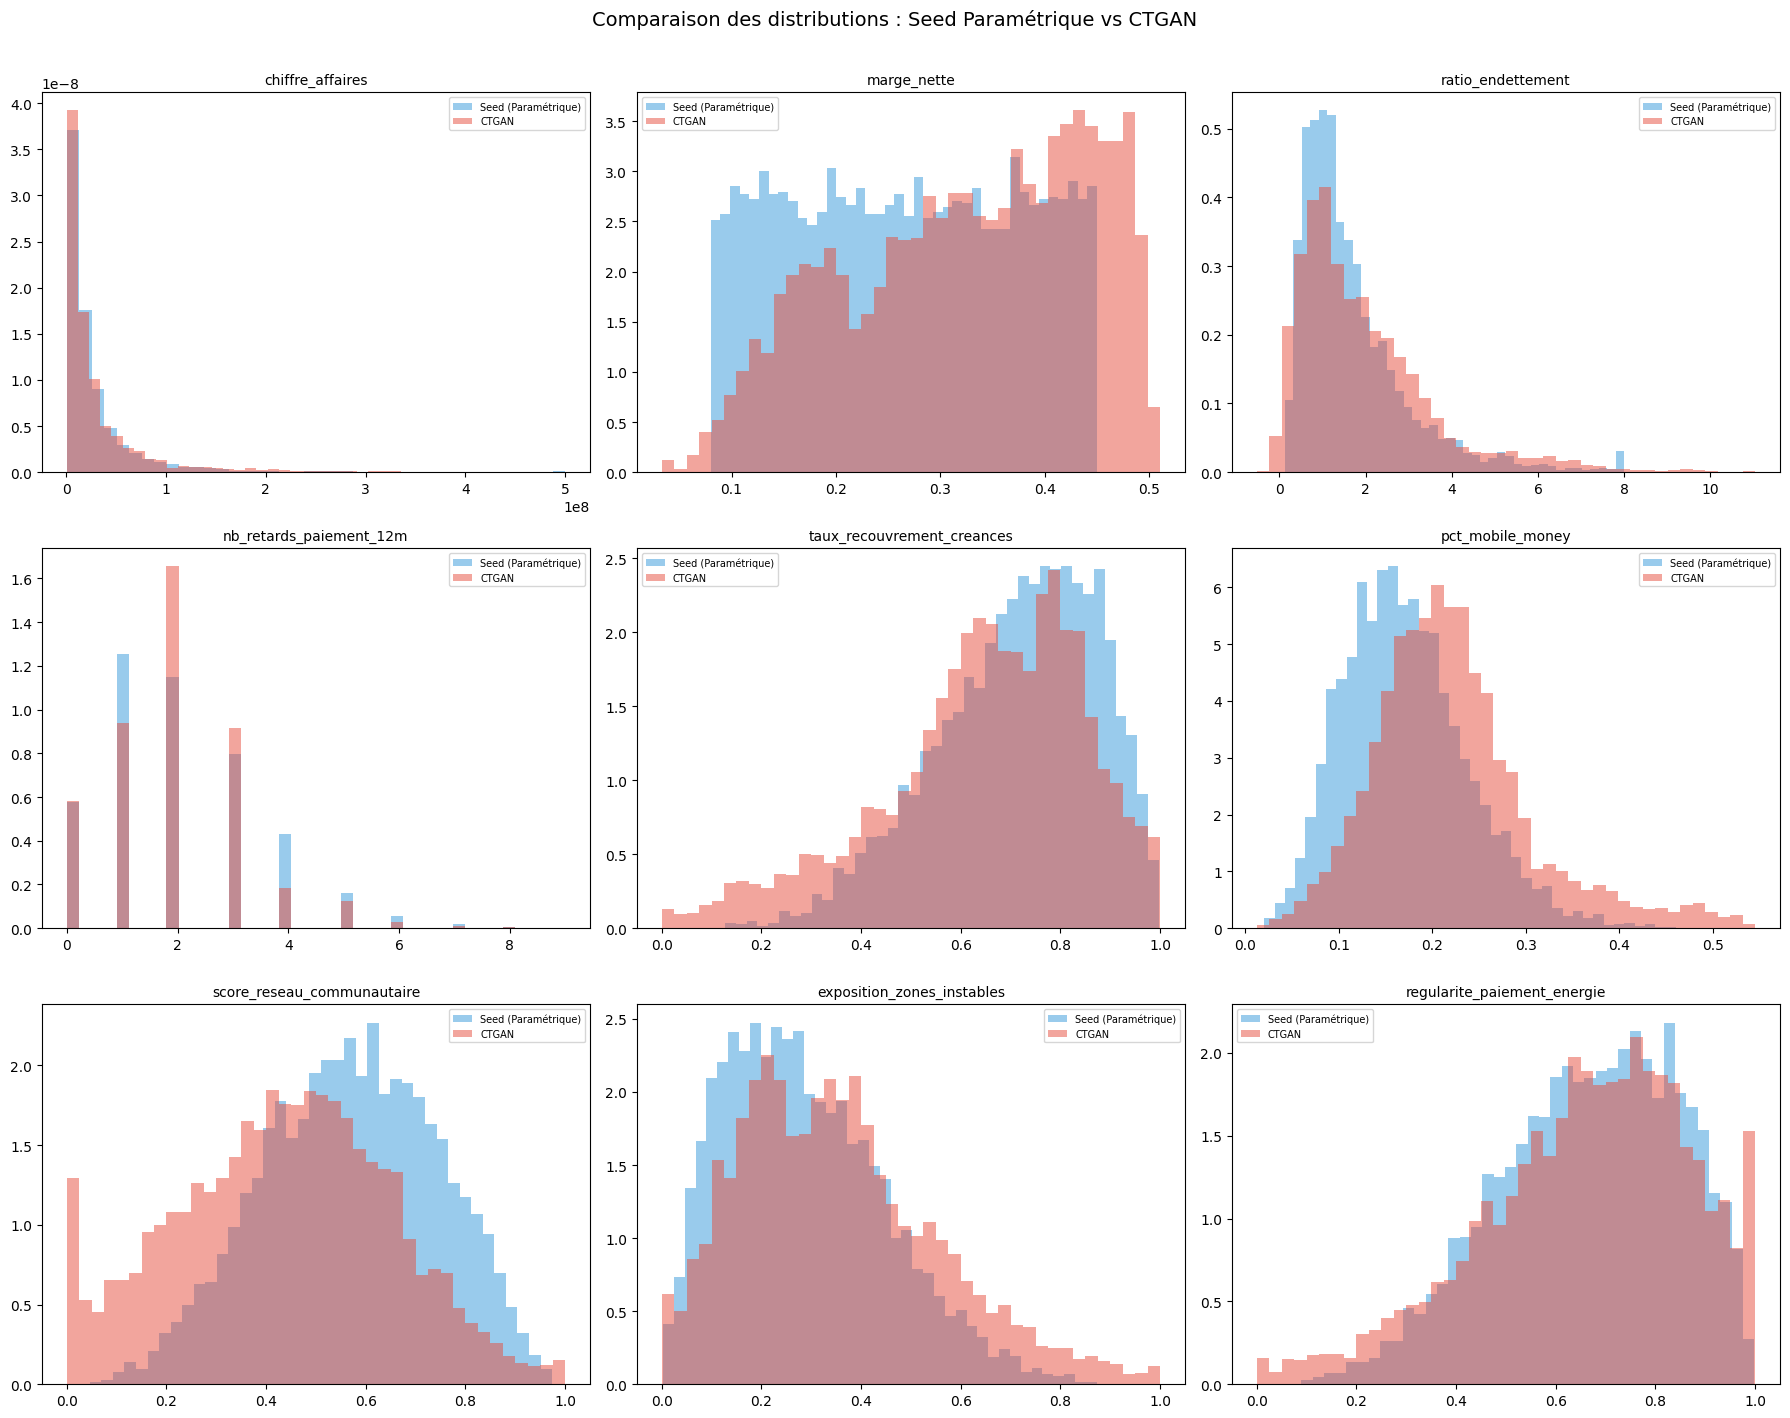

In [5]:
# Comparaison des distributions clés : Seed (paramétrique) vs CTGAN
compare_cols = ['chiffre_affaires', 'marge_nette', 'ratio_endettement',
                'nb_retards_paiement_12m', 'taux_recouvrement_creances',
                'pct_mobile_money', 'score_reseau_communautaire',
                'exposition_zones_instables', 'regularite_paiement_energie']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    ax = axes[i]
    if col in data_seed.select_dtypes(include=np.number).columns:
        ax.hist(data_seed[col].dropna(), bins=40, alpha=0.5, color='#3498db',
                label='Seed (Paramétrique)', density=True)
        ax.hist(data_ctgan[col].dropna(), bins=40, alpha=0.5, color='#e74c3c',
                label='CTGAN', density=True)
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=7)

plt.suptitle('Comparaison des distributions : Seed Paramétrique vs CTGAN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Statistiques comparatives
from scipy import stats

print("=" * 75)
print("VALIDATION STATISTIQUE — Seed Paramétrique vs CTGAN")
print("=" * 75)
print(f"{'Variable':<35} {'Moy Seed':>10} {'Moy CTGAN':>10} {'KS stat':>10} {'p-value':>10}")
print("-" * 75)

num_cols = data_seed.select_dtypes(include=np.number).columns
ks_results = []
for col in num_cols:
    if col in data_ctgan.columns:
        ks_stat, p_val = stats.ks_2samp(data_seed[col].dropna(), data_ctgan[col].dropna())
        ks_results.append({'Variable': col, 'KS': ks_stat, 'p_value': p_val})
        mean_seed = data_seed[col].mean()
        mean_ctgan = data_ctgan[col].mean()
        flag = '⚠️' if p_val < 0.05 else '✅'
        print(f"{flag} {col:<33} {mean_seed:>10.3f} {mean_ctgan:>10.3f} {ks_stat:>10.4f} {p_val:>10.4f}")

ks_df = pd.DataFrame(ks_results)
n_similar = (ks_df['p_value'] >= 0.05).sum()
print(f"\n📊 Résumé : {n_similar}/{len(ks_df)} variables avec distribution similaire (KS test p≥0.05)")
print(f"   Variables divergentes : {(ks_df['p_value'] < 0.05).sum()}")

VALIDATION STATISTIQUE — Seed Paramétrique vs CTGAN
Variable                              Moy Seed  Moy CTGAN    KS stat    p-value
---------------------------------------------------------------------------
⚠️ anciennete_annees                      5.132      4.467     0.1288     0.0000
⚠️ nb_employes                            9.832     11.948     0.1138     0.0000
⚠️ chiffre_affaires                  28343766.932 32894919.574     0.1194     0.0000
⚠️ nb_transactions_mois                  79.848     82.450     0.1444     0.0000
⚠️ montant_moyen_transaction          29943.299  28796.259     0.1130     0.0000
⚠️ pct_cash                               0.799      0.833     0.2006     0.0000
⚠️ pct_mobile_money                       0.171      0.222     0.2754     0.0000
⚠️ pct_banque                             0.030      0.037     0.0844     0.0000
⚠️ diversification_paiement               0.320      0.258     0.2562     0.0000
⚠️ pct_transactions_usd                   0.497      0.425 

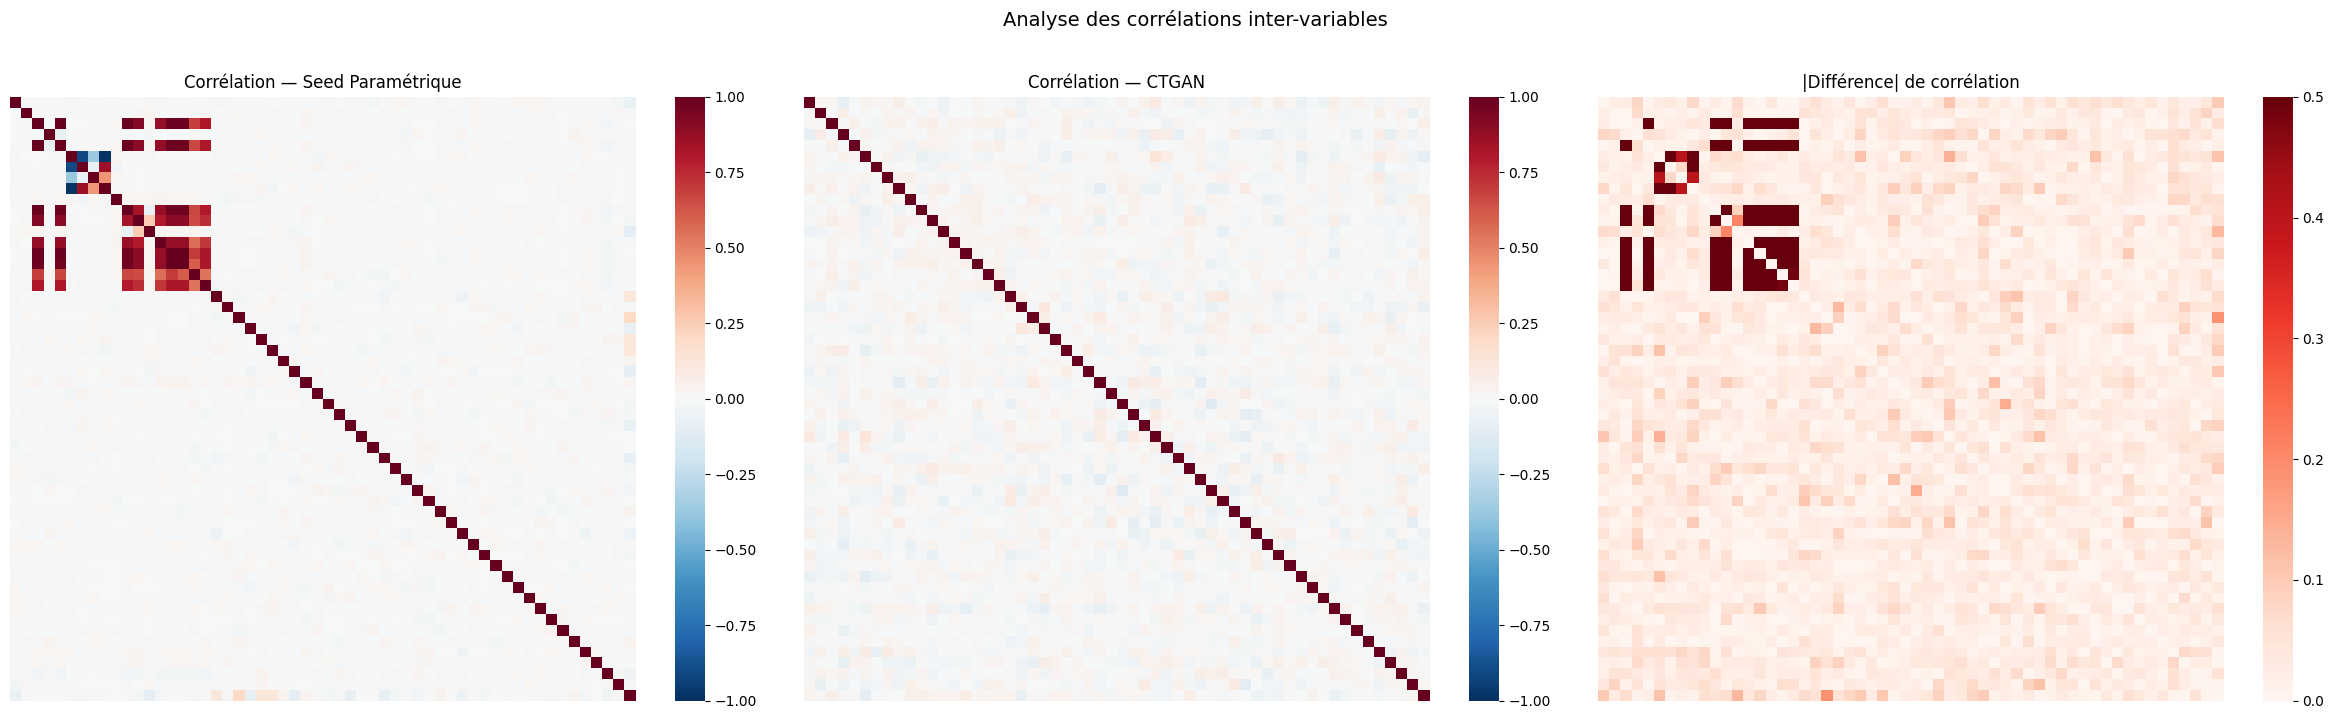


📊 Écart moyen de corrélation (triangle supérieur) : 0.0489
   Interprétation : Bonne fidélité


In [7]:
# Comparaison des matrices de corrélation
num_seed = data_seed.select_dtypes(include=np.number)
num_ctgan = data_ctgan.select_dtypes(include=np.number)
common_cols = [c for c in num_seed.columns if c in num_ctgan.columns]

corr_seed = num_seed[common_cols].corr()
corr_ctgan = num_ctgan[common_cols].corr()
corr_diff = (corr_seed - corr_ctgan).abs()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(corr_seed, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
axes[0].set_title('Corrélation — Seed Paramétrique', fontsize=12)

sns.heatmap(corr_ctgan, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
axes[1].set_title('Corrélation — CTGAN', fontsize=12)

sns.heatmap(corr_diff, ax=axes[2], cmap='Reds', vmin=0, vmax=0.5,
            xticklabels=False, yticklabels=False)
axes[2].set_title('|Différence| de corrélation', fontsize=12)

plt.suptitle('Analyse des corrélations inter-variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

mean_corr_diff = corr_diff.values[np.triu_indices_from(corr_diff, k=1)].mean()
print(f"\n📊 Écart moyen de corrélation (triangle supérieur) : {mean_corr_diff:.4f}")
print(f"   Interprétation : {'Bonne fidélité' if mean_corr_diff < 0.1 else 'Divergences notables'}")

## 4. Feature Engineering (identique au Notebook 1)

Pipeline de feature engineering identique pour assurer la comparabilité.

In [8]:
# Utilisation des données CTGAN pour l'entraînement
data = data_ctgan.copy()

# === Ratios transactionnels ERP ===
data['ca_par_employe'] = (data['chiffre_affaires'] / data['nb_employes'].clip(lower=1)).round(0)
data['charges_ratio'] = (data['charges_exploitation'] / data['chiffre_affaires'].clip(lower=1)).round(4)
data['flux_net_ratio'] = (data['flux_tresorerie_net'] / data['entrees_tresorerie_mois'].clip(lower=1)).round(4)
data['intensite_retards'] = data['nb_retards_paiement_12m'] * data['jours_retard_moyen']
data['tresorerie_par_employe'] = (data['solde_caisse_moyen'] / data['nb_employes'].clip(lower=1)).round(0)
data['charge_remboursement_ratio'] = (
    data['remboursements_dettes_mois'] / data['entrees_tresorerie_mois'].clip(lower=1)
).round(4)
data['solde_caisse_ratio'] = (data['solde_caisse_moyen'] / data['chiffre_affaires'].clip(lower=1)).round(4)
data['score_comportement_transactionnel'] = (
    data['regularite_paiement_fournisseurs'] * 0.30 +
    data['regularite_paiement_mobile'] * 0.25 +
    data['taux_recouvrement_creances'] * 0.25 +
    (1 - data['nb_factures_impayees'] / data['nb_factures_impayees'].clip(lower=1).max()) * 0.20
).round(4)

# === Scores composites CET ===
data['score_reseau_reputation'] = (
    data['score_reseau_communautaire'] * 0.25 +
    data['appartenance_association'] * 0.25 +
    data['pct_clients_recurrents'] * 0.25 +
    data['score_reputation_terrain'] * 0.25
).round(4)
data['score_robustesse_contextuelle'] = (
    data['diversification_activites'] * 0.30 +
    (1 - data['exposition_zones_instables']) * 0.30 +
    (data['stock_securite_jours'] / 90).clip(0, 1) * 0.20 +
    (1 - data['variabilite_ca'] / 0.6).clip(0, 1) * 0.20
).round(4)
data['creances_deviation_norme'] = (data['creances_sur_ca'] / 1.28).round(3)
data['score_psychometrie'] = (
    data['score_debrouillardise'] * 0.50 +
    data['usage_whatsapp_business'] * 0.20 +
    (data['anciennete_annees'] / 30).clip(0, 1) * 0.30
).round(4)

# === Indicateurs alternatifs dérivés ===
data['score_presence_digitale'] = (
    np.log1p(data['social_media_abonnes']) * 0.3 +
    np.log1p(data['trafic_web_mensuel']) * 0.3 +
    data['note_avis_moyenne'] / 5 * 0.2 +
    np.log1p(data['nb_avis_en_ligne']) * 0.2
).round(4)
data['score_regularite_utilites'] = (
    data['regularite_paiement_energie'] * 0.35 +
    data['regularite_paiement_eau'] * 0.30 +
    data['regularite_paiement_loyer'] * 0.35
).round(4)
data['energie_par_employe'] = (data['conso_energie_kwh'] / data['nb_employes'].clip(lower=1)).round(2)
data['eau_par_employe'] = (data['conso_eau_m3'] / data['nb_employes'].clip(lower=1)).round(2)
data['anciennete_log'] = np.log1p(data['anciennete_annees']).round(4)
data['employes_log'] = np.log1p(data['nb_employes']).round(4)

print(f"✅ Features ajoutées sur données CTGAN — Total : {data.shape[1]} colonnes")

✅ Features ajoutées sur données CTGAN — Total : 77 colonnes


## 5. Préparation des données + Sélection Boruta

In [9]:
# Séparation features / cible
target = 'default'
cat_vars = ['secteur', 'taille', 'localisation']
X = data.drop(columns=[target])
y = data[target]

# Encodage OneHot
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = pd.DataFrame(
    encoder.fit_transform(X[cat_vars]),
    columns=encoder.get_feature_names_out(cat_vars),
    index=X.index
)
X = pd.concat([X.drop(columns=cat_vars), cat_encoded], axis=1)

# Standardisation
num_features = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print(f"✅ X shape = {X.shape}")

✅ X shape = (5000, 92)


In [10]:
# === Sélection Boruta ===
xgb_boruta = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc',
    max_depth=5, learning_rate=0.1, n_estimators=100,
    random_state=42, use_label_encoder=False, verbosity=0
)

boruta_selector = BorutaPy(
    estimator=xgb_boruta, n_estimators='auto',
    max_iter=40, random_state=42, verbose=0
)

print("⏳ Exécution de Boruta sur données CTGAN...")
boruta_selector.fit(X.values, y.values)

selected_features = X.columns[boruta_selector.support_].tolist()
tentative_features = X.columns[boruta_selector.support_weak_].tolist()
final_features = selected_features + tentative_features

print(f"\n✅ Boruta (CTGAN) : {len(selected_features)} confirmées + {len(tentative_features)} tentatives = {len(final_features)} retenues")
for f in sorted(final_features):
    rank = boruta_selector.ranking_[X.columns.tolist().index(f)]
    print(f"   • {f} (rang {rank})")

X = X[final_features]
num_features_boruta = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_features_boruta] = scaler.fit_transform(X[num_features_boruta])
print(f"\n✅ X réduit → {X.shape[1]} features")

⏳ Exécution de Boruta sur données CTGAN...

✅ Boruta (CTGAN) : 4 confirmées + 3 tentatives = 7 retenues
   • entrees_tresorerie_mois (rang 2)
   • localisation_Lubumbashi (rang 1)
   • pct_cash (rang 2)
   • secteur_Agriculture (rang 1)
   • secteur_TIC (rang 2)
   • taille_Micro (rang 1)
   • taille_Petite (rang 1)

✅ X réduit → 7 features


In [11]:
# Division : 80% train / 10% validation / 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train  : {X_train.shape[0]} ({y_train.mean()*100:.1f}% défauts)")
print(f"Valid  : {X_valid.shape[0]} ({y_valid.mean()*100:.1f}% défauts)")
print(f"Test   : {X_test.shape[0]} ({y_test.mean()*100:.1f}% défauts)")

Train  : 4000 (11.9% défauts)
Valid  : 500 (12.0% défauts)
Test   : 500 (12.0% défauts)


## 6. Modélisation XGBoost-B-GHM

In [12]:
import time

# === GHM Loss Function ===
def ghm_loss(y_true, y_pred, bins=7, beta=0.65):
    sigmoid_pred = 1.0 / (1.0 + np.exp(-y_pred))
    g = np.abs(y_true - sigmoid_pred)
    edges = np.linspace(0, 1, bins + 1)
    weights = np.ones_like(g)
    for i in range(bins):
        mask = (g >= edges[i]) & (g < edges[i + 1])
        count = mask.sum()
        if count > 0:
            density = count / (edges[i + 1] - edges[i])
            weights[mask] = len(g) / (density * bins)
    weights = beta * weights + (1 - beta) * 1.0
    grad = weights * (sigmoid_pred - y_true)
    hess = weights * sigmoid_pred * (1 - sigmoid_pred)
    return grad, hess

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio classe négative/positive : {scale_pos:.2f}")

xgb_clf = xgb.XGBClassifier(
    objective=ghm_loss, eval_metric='auc',
    random_state=42, use_label_encoder=False
)

param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600, 800],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}

print(f"RandomizedSearch : 50 combinaisons × 5 folds")

Ratio classe négative/positive : 7.37
RandomizedSearch : 50 combinaisons × 5 folds


In [13]:
# Recherche d'hyperparamètres
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_grid,
    n_iter=50, cv=skf, scoring='roc_auc',
    n_jobs=-1, verbose=1, random_state=42, return_train_score=True
)

start_time = time.time()
random_search.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
elapsed = time.time() - start_time

print(f"\n⏱️ Temps : {elapsed:.1f}s")
print(f"\n🏆 Meilleurs hyperparamètres (CTGAN) :")
for param, val in random_search.best_params_.items():
    print(f"   {param}: {val}")
print(f"\n📊 Meilleur AUC (CV) : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

⏱️ Temps : 391.4s

🏆 Meilleurs hyperparamètres (CTGAN) :
   subsample: 0.8
   reg_lambda: 1
   reg_alpha: 0
   n_estimators: 400
   min_child_weight: 1
   max_depth: 6
   learning_rate: 0.01
   gamma: 0.3
   colsample_bytree: 0.8

📊 Meilleur AUC (CV) : 0.6596


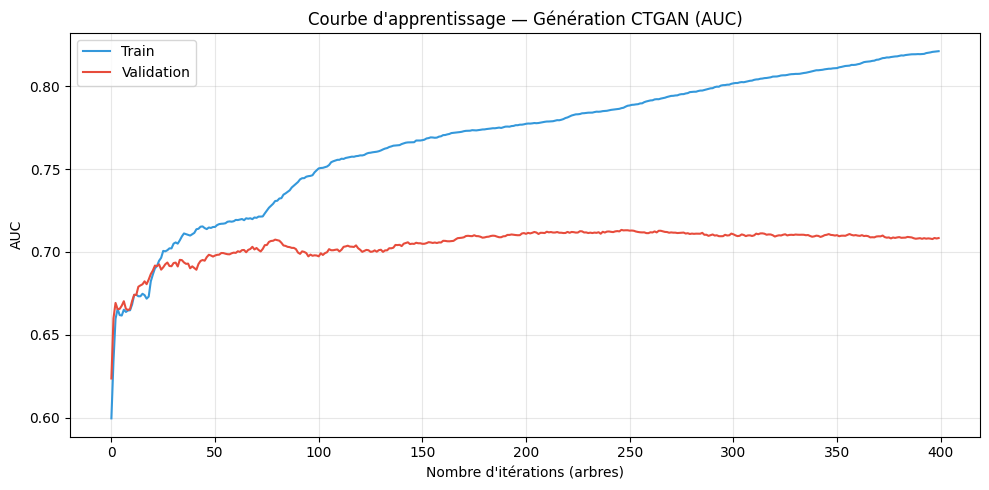

In [14]:
# Réentraînement du meilleur modèle
best_model = random_search.best_estimator_
eval_set = [(X_train, y_train), (X_valid, y_valid)]
best_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results = best_model.evals_result()
eval_metric = list(results['validation_0'].keys())[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0'][eval_metric], label='Train', color='#3498db')
ax.plot(results['validation_1'][eval_metric], label='Validation', color='#e74c3c')
ax.set_xlabel("Nombre d'itérations (arbres)")
ax.set_ylabel(eval_metric.upper())
ax.set_title(f"Courbe d'apprentissage — Génération CTGAN ({eval_metric.upper()})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Évaluation du modèle

In [ ]:
# Prédictions sur le jeu de test
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("MÉTRIQUES — XGBoost-B-GHM (Génération CTGAN)")
print("=" * 60)
print(f"\nAccuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC-PR      : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"Brier Score : {brier_score_loss(y_test, y_pred_proba):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Sain', 'Défaut']))

# Sauvegarder les métriques
metrics_ctgan = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
    'AUC-PR': average_precision_score(y_test, y_pred_proba),
    'Brier Score': brier_score_loss(y_test, y_pred_proba)
}
joblib.dump(metrics_ctgan, 'data/metrics_ctgan.pkl')
print("💾 Métriques sauvegardées → data/metrics_ctgan.pkl")

MÉTRIQUES — XGBoost-B-GHM (Génération CTGAN)

Accuracy    : 0.8760
Precision   : 0.2500
Recall      : 0.0167
F1-Score    : 0.0312
AUC-ROC     : 0.6480
AUC-PR      : 0.2132
Brier Score : 0.1068

              precision    recall  f1-score   support

        Sain       0.88      0.99      0.93       440
      Défaut       0.25      0.02      0.03        60

    accuracy                           0.88       500
   macro avg       0.57      0.50      0.48       500
weighted avg       0.81      0.88      0.83       500

💾 Métriques sauvegardées → metrics_ctgan.pkl


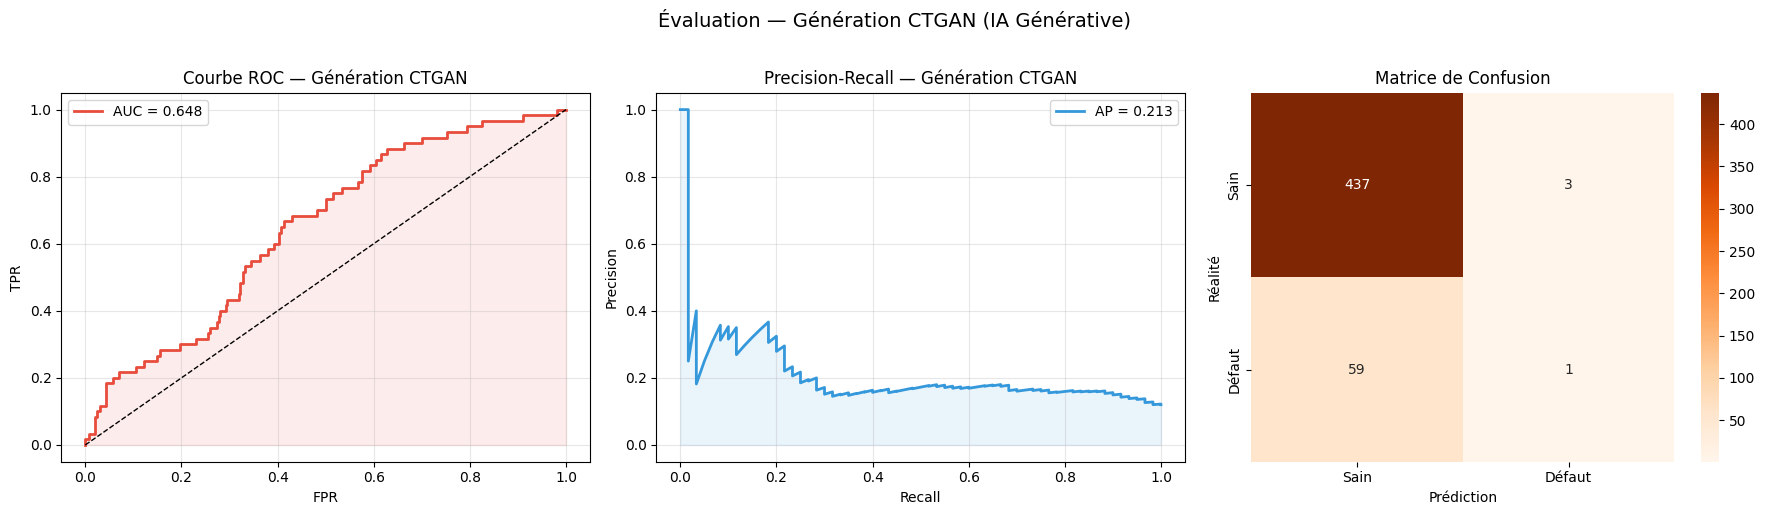

In [16]:
# Courbe ROC, Precision-Recall, Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Courbe ROC — Génération CTGAN')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)
axes[1].plot(recall_vals, precision_vals, color='#3498db', lw=2, label=f'AP = {ap_score:.3f}')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — Génération CTGAN')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Sain', 'Défaut'], yticklabels=['Sain', 'Défaut'])
axes[2].set_xlabel('Prédiction'); axes[2].set_ylabel('Réalité')
axes[2].set_title('Matrice de Confusion')

plt.suptitle('Évaluation — Génération CTGAN (IA Générative)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

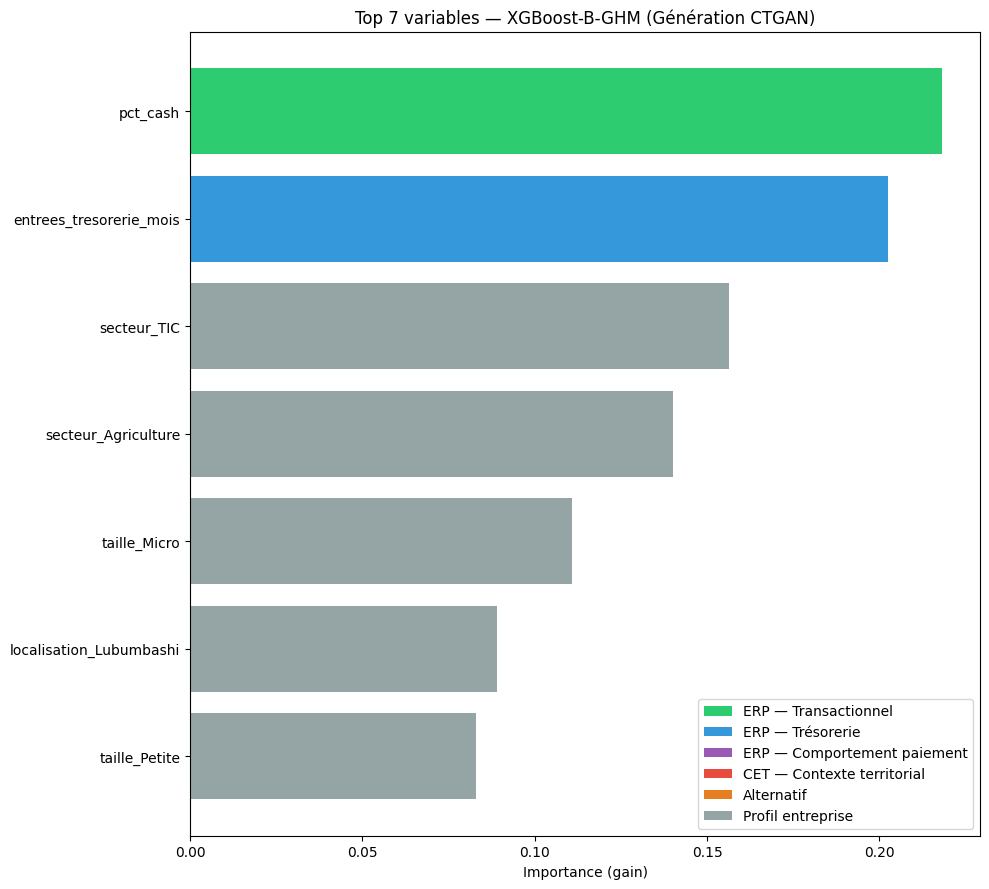

In [17]:
# Importance des variables
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

def categorize_feature(name):
    contextuel_cet = ['informelle', 'ecart_taux', 'association', 'reseau', 'clients_recurrents',
                      'reputation', 'credit_informel', 'exposition_zones', 'diversification_activites',
                      'stock_securite', 'debrouillardise', 'whatsapp', 'robustesse',
                      'psychometrie', 'creances_deviation']
    erp_transac = ['pct_cash', 'pct_mobile', 'pct_banque', 'diversification', 'nb_transactions',
                   'montant_moyen', 'pct_transactions_usd']
    erp_tresorie = ['chiffre_affaires', 'charges', 'resultat', 'marge', 'flux', 'tresorerie',
                    'solde_caisse', 'entrees', 'sorties', 'remboursements', 'ratio_liquidite',
                    'ratio_endettement', 'couverture', 'ca_par', 'charges_ratio', 'flux_net',
                    'charge_remboursement', 'solde_caisse_ratio', 'variabilite_ca']
    erp_comportement = ['retards', 'jours_retard', 'factures', 'taux_recouvrement', 'delai_paiement',
                        'regularite_paiement_mobile', 'regularite_paiement_fournisseurs',
                        'intensite', 'score_comportement', 'delai_recouvrement', 'creances_sur_ca']
    alternative = ['social', 'conso', 'tendance', 'trafic', 'avis', 'note', 'regularite_paiement_energie',
                   'regularite_paiement_eau', 'regularite_paiement_loyer', 'energie_par', 'eau_par',
                   'score_presence', 'score_regularite_utilites']
    for kw in contextuel_cet:
        if kw in name.lower(): return '#e74c3c'
    for kw in erp_transac:
        if kw in name.lower(): return '#2ecc71'
    for kw in erp_tresorie:
        if kw in name.lower(): return '#3498db'
    for kw in erp_comportement:
        if kw in name.lower(): return '#9b59b6'
    for kw in alternative:
        if kw in name.lower(): return '#e67e22'
    return '#95a5a6'

top_n = min(25, len(feature_importances))
top_features_plot = feature_importances.tail(top_n)
colors = [categorize_feature(f) for f in top_features_plot['Feature']]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_features_plot['Feature'], top_features_plot['Importance'], color=colors)
ax.set_title(f'Top {top_n} variables — XGBoost-B-GHM (Génération CTGAN)')
ax.set_xlabel('Importance (gain)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='ERP — Transactionnel'),
    Patch(facecolor='#3498db', label='ERP — Trésorerie'),
    Patch(facecolor='#9b59b6', label='ERP — Comportement paiement'),
    Patch(facecolor='#e74c3c', label='CET — Contexte territorial'),
    Patch(facecolor='#e67e22', label='Alternatif'),
    Patch(facecolor='#95a5a6', label='Profil entreprise')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 8. Explicabilité — Visualisation des Arbres XGBoost

Le choix de XGBoost repose sur son **explicabilité** : chaque arbre est un ensemble de règles interprétables.
On compare la structure des arbres obtenus avec les données CTGAN vs les données classiques.

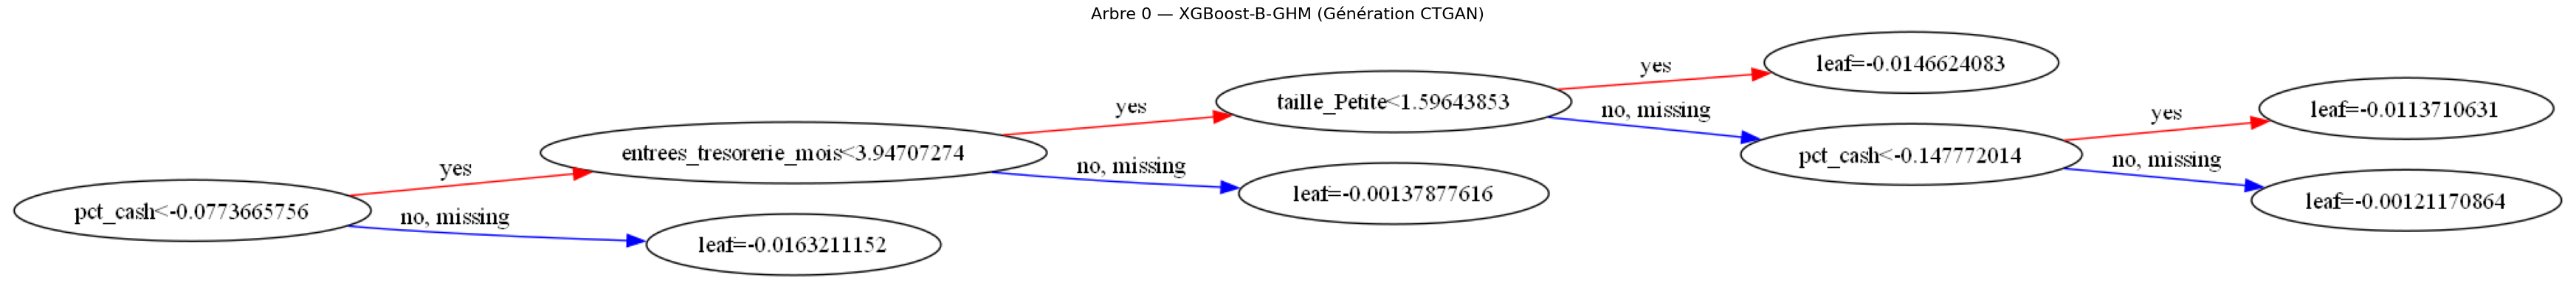

💾 Arbre sauvegardé → arbre_0_ctgan.png


In [ ]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

# === Visualisation de la structure des arbres XGBoost — CTGAN ===
fig, ax = plt.subplots(figsize=(35, 20))
xgb.plot_tree(best_model, num_trees=0, ax=ax, rankdir='LR')
ax.set_title("Arbre 0 — XGBoost-B-GHM (Génération CTGAN)", fontsize=16)
plt.tight_layout()
plt.savefig('papers/figures/arbre_0_ctgan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Arbre sauvegardé : papers/figures/arbre_0_ctgan.png")

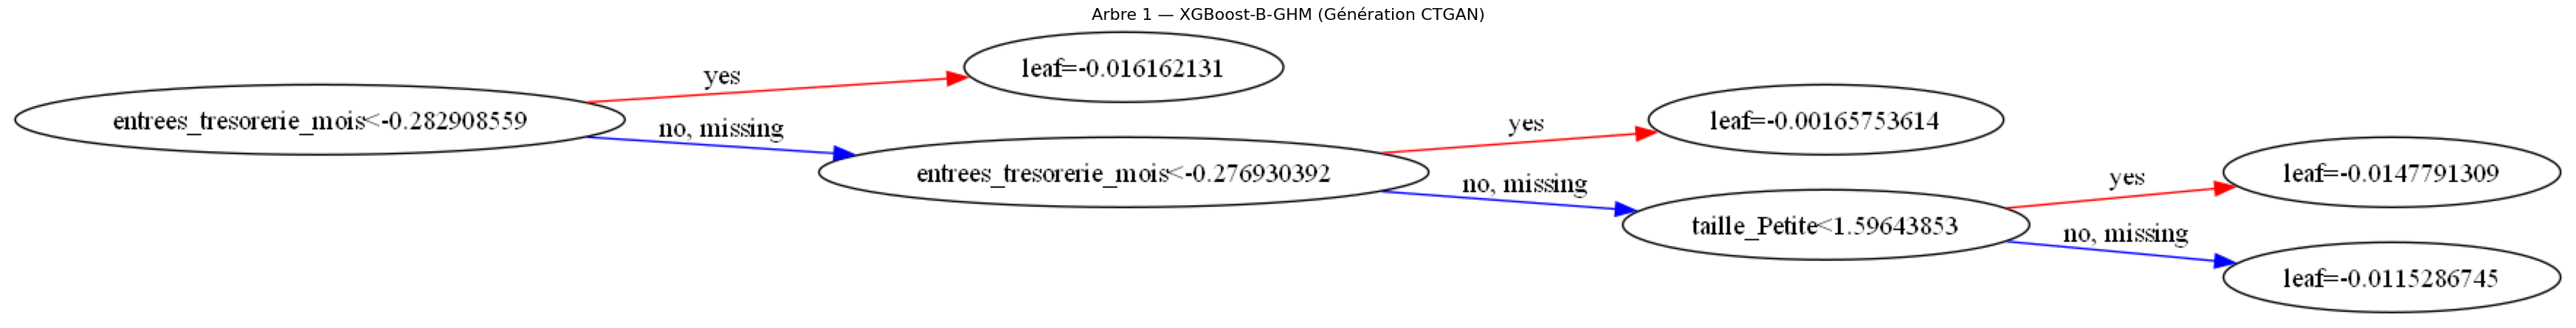

💾 Arbre 1 sauvegardé


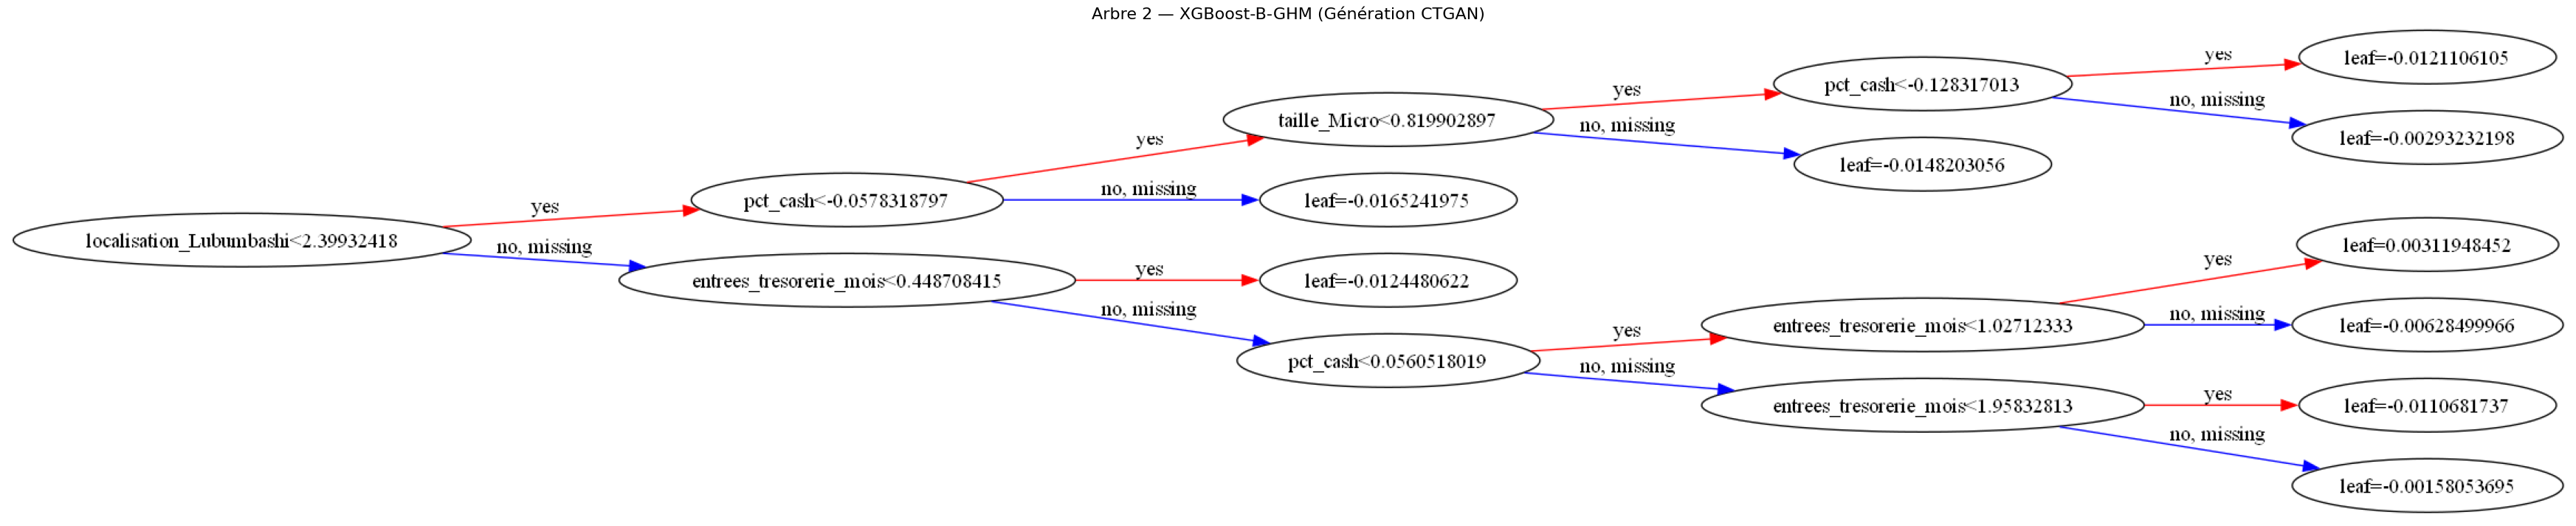

💾 Arbre 2 sauvegardé


In [ ]:
# Arbres 1 et 2
for tree_idx in [1, 2]:
    fig, ax = plt.subplots(figsize=(35, 20))
    xgb.plot_tree(best_model, num_trees=tree_idx, ax=ax, rankdir='LR')
    ax.set_title(f"Arbre {tree_idx} — XGBoost-B-GHM (Génération CTGAN)", fontsize=16)
    plt.tight_layout()
    plt.savefig(f'papers/figures/arbre_{tree_idx}_ctgan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Arbre {tree_idx} sauvegardé")

In [20]:
# === Statistiques sur la structure des arbres ===
booster = best_model.get_booster()
trees_df = booster.trees_to_dataframe()

n_trees = trees_df['Tree'].nunique()

def tree_max_depth(tree_group):
    depth = {}
    for _, row in tree_group.iterrows():
        depth[row['ID']] = 0
    for _, row in tree_group.iterrows():
        if row['Feature'] != 'Leaf':
            for child_col in ['Yes', 'No', 'Missing']:
                child = row.get(child_col)
                if pd.notna(child) and child in depth:
                    depth[child] = depth.get(row['ID'], 0) + 1
    return max(depth.values()) if depth else 0

depths = trees_df.groupby('Tree').apply(tree_max_depth)
avg_depth = depths.mean()
avg_leaves = trees_df[trees_df['Feature'] == 'Leaf'].groupby('Tree').size().mean()
top_split_features = trees_df[trees_df['Feature'] != 'Leaf']['Feature'].value_counts().head(10)

print("=" * 60)
print("STRUCTURE DU MODÈLE XGBoost — Génération CTGAN")
print("=" * 60)
print(f"Nombre total d'arbres       : {n_trees}")
print(f"Profondeur moyenne           : {avg_depth:.1f}")
print(f"Nombre moyen de feuilles     : {avg_leaves:.1f}")
print(f"\nTop variables de split :")
for feat, count in top_split_features.items():
    print(f"   {feat:40s} : {count:4d} splits")

STRUCTURE DU MODÈLE XGBoost — Génération CTGAN
Nombre total d'arbres       : 400
Profondeur moyenne           : 5.8
Nombre moyen de feuilles     : 22.4

Top variables de split :
   entrees_tresorerie_mois                  : 3545 splits
   pct_cash                                 : 3309 splits
   localisation_Lubumbashi                  :  495 splits
   taille_Micro                             :  386 splits
   secteur_Agriculture                      :  310 splits
   taille_Petite                            :  303 splits
   secteur_TIC                              :  214 splits


## 9. Analyse SHAP

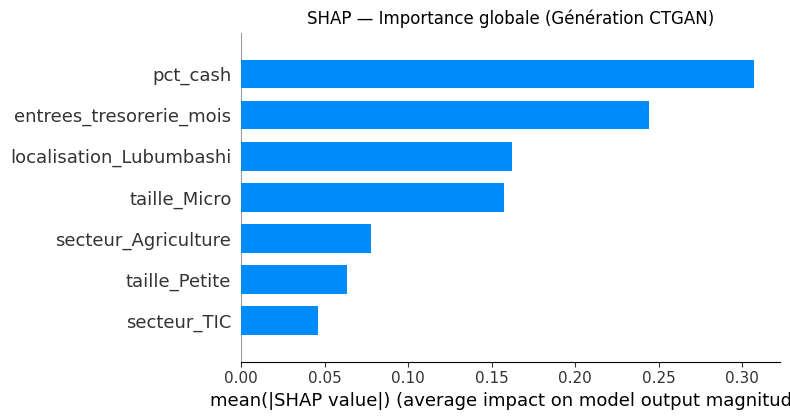

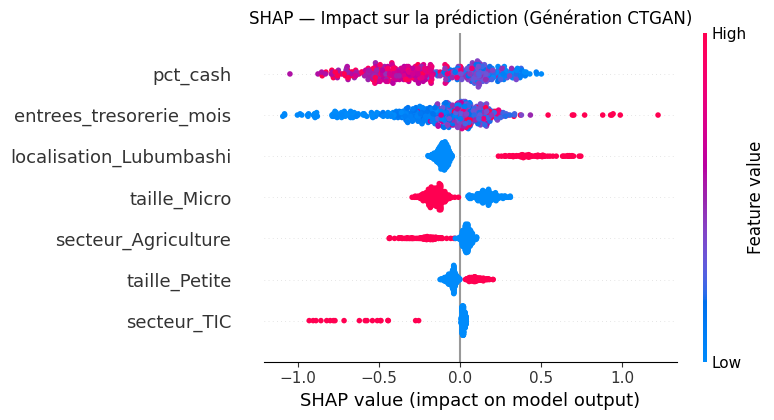

In [21]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20, show=False)
plt.title('SHAP — Importance globale (Génération CTGAN)')
plt.tight_layout()
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP — Impact sur la prédiction (Génération CTGAN)')
plt.tight_layout()
plt.show()

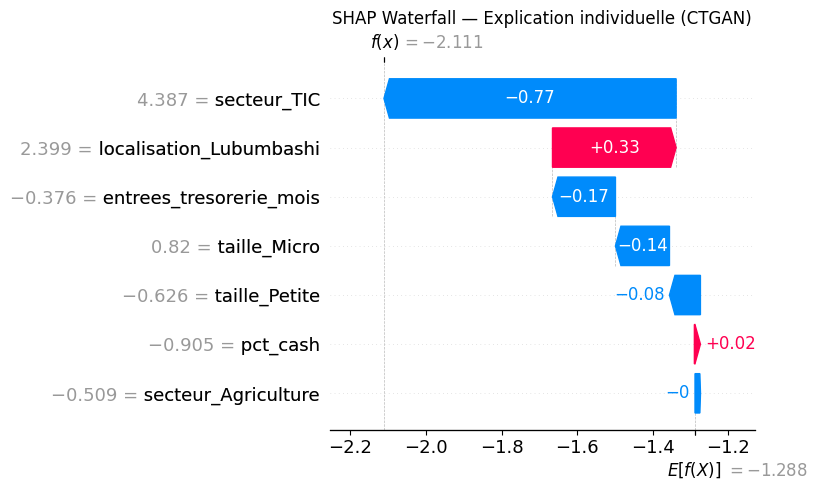

In [22]:
# SHAP — Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
)
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall — Explication individuelle (CTGAN)')
plt.tight_layout()
plt.show()

## 10. Comparaison finale — Classique vs CTGAN

Synthèse des résultats : quel mode de génération produit le meilleur modèle XGBoost ?

In [ ]:
# Charger les métriques du Notebook 1
try:
    metrics_classique = joblib.load('data/metrics_classique.pkl')
    print("✅ Métriques du Notebook 1 (Classique) chargées")
except FileNotFoundError:
    print("⚠️ data/metrics_classique.pkl non trouvé — Exécutez d'abord le Notebook 1")
    metrics_classique = None

if metrics_classique is not None:
    # Tableau comparatif
    comparison = pd.DataFrame({
        'Métrique': list(metrics_ctgan.keys()),
        'Classique (Paramétrique)': list(metrics_classique.values()),
        'CTGAN (IA Générative)': list(metrics_ctgan.values())
    }).round(4)
    
    # Calcul de l'amélioration
    comparison['Δ (CTGAN - Classique)'] = (
        comparison['CTGAN (IA Générative)'] - comparison['Classique (Paramétrique)']
    ).round(4)
    
    # Pour Brier Score, une baisse est une amélioration
    comparison['Meilleur'] = comparison.apply(
        lambda row: 'CTGAN' if (
            (row['Métrique'] != 'Brier Score' and row['Δ (CTGAN - Classique)'] > 0) or
            (row['Métrique'] == 'Brier Score' and row['Δ (CTGAN - Classique)'] < 0)
        ) else 'Classique', axis=1
    )
    
    print("\n" + "=" * 80)
    print("COMPARAISON FINALE — Génération Classique vs CTGAN")
    print("=" * 80)
    print(comparison.to_string(index=False))
    
    n_ctgan_wins = (comparison['Meilleur'] == 'CTGAN').sum()
    n_classique_wins = (comparison['Meilleur'] == 'Classique').sum()
    print(f"\n📊 Score : Classique {n_classique_wins} — CTGAN {n_ctgan_wins} (sur {len(comparison)} métriques)")

✅ Métriques du Notebook 1 (Classique) chargées

COMPARAISON FINALE — Génération Classique vs CTGAN
   Métrique  Classique (Paramétrique)  CTGAN (IA Générative)  Δ (CTGAN - Classique)  Meilleur
   Accuracy                    0.8740                 0.8760                 0.0020     CTGAN
  Precision                    0.5385                 0.2500                -0.2885 Classique
     Recall                    0.1094                 0.0167                -0.0927 Classique
   F1-Score                    0.1818                 0.0312                -0.1506 Classique
    AUC-ROC                    0.7667                 0.6480                -0.1187 Classique
     AUC-PR                    0.4219                 0.2132                -0.2087 Classique
Brier Score                    0.0952                 0.1068                 0.0116 Classique

📊 Score : Classique 6 — CTGAN 1 (sur 7 métriques)


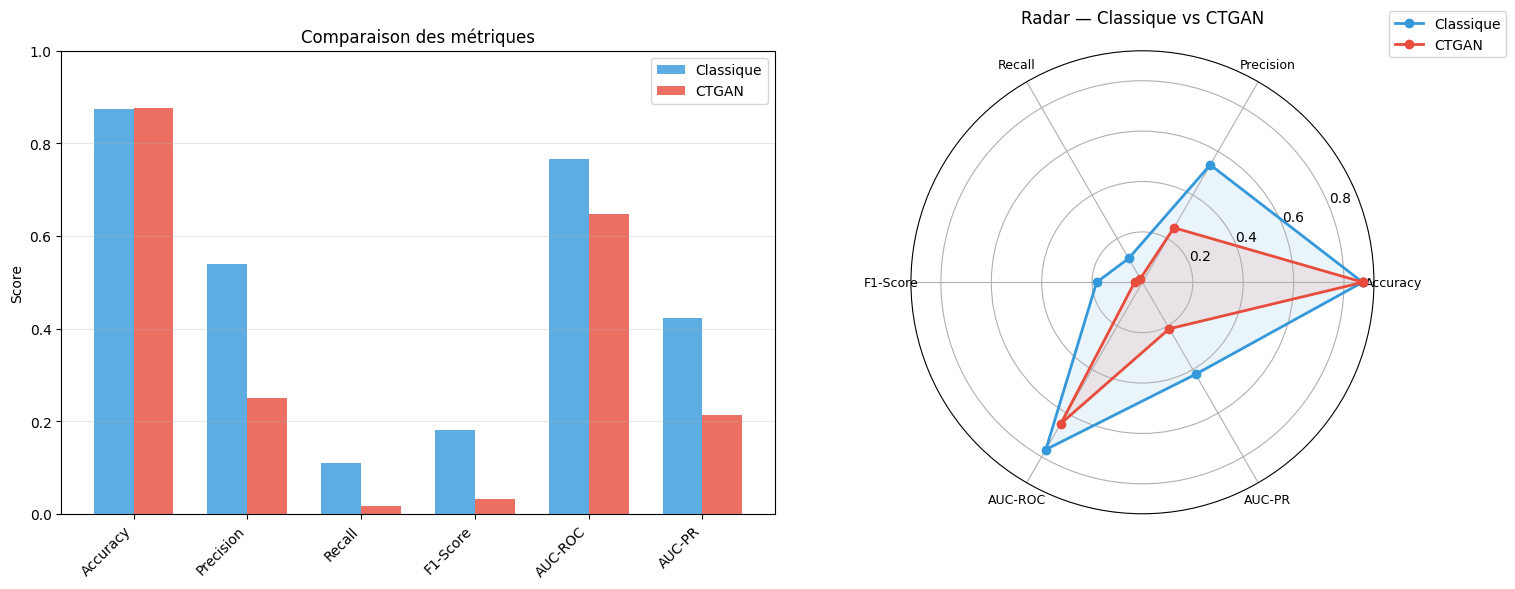

💾 Comparaison sauvegardée → comparaison_classique_vs_ctgan.png


In [ ]:
# Visualisation comparative
if metrics_classique is not None:
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart comparatif
    x = np.arange(len(metrics_to_plot))
    width = 0.35
    vals_classique = [metrics_classique[m] for m in metrics_to_plot]
    vals_ctgan = [metrics_ctgan[m] for m in metrics_to_plot]
    
    axes[0].bar(x - width/2, vals_classique, width, label='Classique', color='#3498db', alpha=0.8)
    axes[0].bar(x + width/2, vals_ctgan, width, label='CTGAN', color='#e74c3c', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Comparaison des métriques')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].set_ylim(0, 1)
    
    # Radar chart
    angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
    vals_classique_r = vals_classique + [vals_classique[0]]
    vals_ctgan_r = vals_ctgan + [vals_ctgan[0]]
    angles_r = angles + [angles[0]]
    
    ax_radar = axes[1]
    ax_radar.remove()
    ax_radar = fig.add_subplot(122, polar=True)
    ax_radar.plot(angles_r, vals_classique_r, 'o-', label='Classique', color='#3498db', lw=2)
    ax_radar.fill(angles_r, vals_classique_r, alpha=0.1, color='#3498db')
    ax_radar.plot(angles_r, vals_ctgan_r, 'o-', label='CTGAN', color='#e74c3c', lw=2)
    ax_radar.fill(angles_r, vals_ctgan_r, alpha=0.1, color='#e74c3c')
    ax_radar.set_xticks(angles)
    ax_radar.set_xticklabels(metrics_to_plot, fontsize=9)
    ax_radar.set_title('Radar — Classique vs CTGAN', fontsize=12, pad=20)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    plt.savefig('papers/figures/comparaison_classique_vs_ctgan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Comparaison sauvegardée : papers/figures/comparaison_classique_vs_ctgan.png")

## 11. Credit Scoring (300-850)

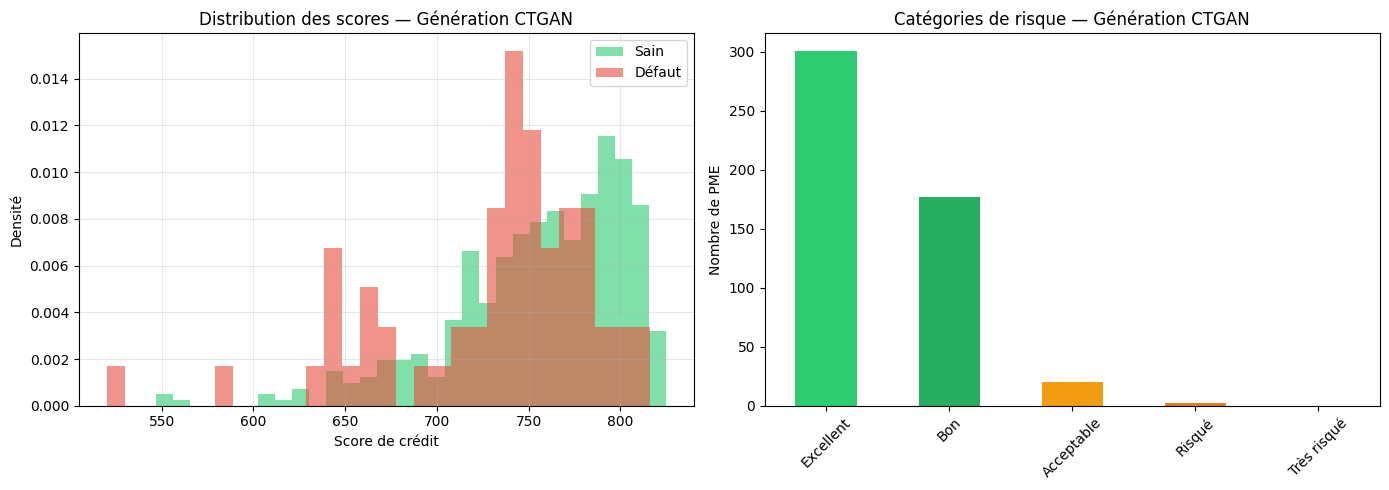


📊 Répartition des catégories de risque :
  Excellent       :  301 PME ( 60.2%) — Taux défaut : 8.6%
  Bon             :  177 PME ( 35.4%) — Taux défaut : 15.3%
  Acceptable      :   20 PME (  4.0%) — Taux défaut : 30.0%
  Risqué          :    2 PME (  0.4%) — Taux défaut : 50.0%


In [25]:
def probability_to_credit_score(prob_default, min_score=300, max_score=850):
    return ((1 - prob_default) * (max_score - min_score) + min_score).round(0).astype(int)

def get_risk_category(score):
    if score >= 750: return 'Excellent'
    elif score >= 650: return 'Bon'
    elif score >= 550: return 'Acceptable'
    elif score >= 450: return 'Risqué'
    else: return 'Très risqué'

scores = probability_to_credit_score(y_pred_proba)
risk_categories = pd.Series(scores).apply(get_risk_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores[y_test == 0], bins=30, alpha=0.6, color='#2ecc71', label='Sain', density=True)
axes[0].hist(scores[y_test == 1], bins=30, alpha=0.6, color='#e74c3c', label='Défaut', density=True)
axes[0].set_xlabel('Score de crédit'); axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution des scores — Génération CTGAN')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

cat_counts = risk_categories.value_counts().reindex(['Excellent', 'Bon', 'Acceptable', 'Risqué', 'Très risqué'])
colors_cat = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
cat_counts.plot(kind='bar', ax=axes[1], color=colors_cat)
axes[1].set_title('Catégories de risque — Génération CTGAN')
axes[1].set_ylabel('Nombre de PME')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📊 Répartition des catégories de risque :")
for cat in ['Excellent', 'Bon', 'Acceptable', 'Risqué', 'Très risqué']:
    mask = risk_categories == cat
    count = mask.sum()
    if count > 0:
        default_rate = y_test.values[mask.values].mean() * 100
        print(f"  {cat:15s} : {count:4d} PME ({count/len(scores)*100:5.1f}%) — Taux défaut : {default_rate:.1f}%")

## 12. Sauvegarde du modèle

In [ ]:
model_artifacts = {
    'model': best_model,
    'encoder': encoder,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'best_params': random_search.best_params_,
    'best_auc_cv': random_search.best_score_,
    'boruta_selected': final_features,
    'metrics': metrics_ctgan,
    'generation_method': 'ctgan_generative_ai',
    'ctgan_model': ctgan,
    'metadata': {
        'version': 'v3.0-ctgan',
        'model_type': 'XGBoost-Boruta-GHM',
        'data_generation': 'CTGAN (Conditional Tabular GAN — Xu et al. 2019)',
        'ctgan_epochs': 300,
        'ctgan_batch_size': 500,
        'N': N_gen,
        'n_features_boruta': len(final_features),
        'description': 'Notebook 2 — Génération par IA Générative (CTGAN)'
    }
}

joblib.dump(model_artifacts, 'models/model_ctgan_xgboost_bghm.pkl')
best_model.save_model('models/model_ctgan_xgboost_bghm.json')
print("Modele CTGAN sauvegarde")
print(f"   models/model_ctgan_xgboost_bghm.pkl")
print(f"   models/model_ctgan_xgboost_bghm.json")
print(f"   data/metrics_ctgan.pkl")
print(f"   papers/figures/comparaison_classique_vs_ctgan.png")

✅ Modèle CTGAN sauvegardé
   → model_ctgan_xgboost_bghm.pkl
   → model_ctgan_xgboost_bghm.json
   → metrics_ctgan.pkl
   → comparaison_classique_vs_ctgan.png


---

## Synthèse

| Aspect | Classique (NB1) | CTGAN (NB2) |
|--------|----------------|-------------|
| **Génération** | Distributions paramétriques indépendantes | GAN conditionnel (distribution jointe) |
| **Corrélations** | Implicites via le logit | Apprises automatiquement |
| **Contrôlabilité** | Haute (chaque paramètre ajustable) | Faible (boîte noire) |
| **Réalisme** | Dépend de l'expertise du calibrage | Dépend de la qualité du seed |
| **Modèle XGBoost** | XGBoost-B-GHM identique | XGBoost-B-GHM identique |
| **Explicabilité** | Arbres de décision interprétables | Arbres de décision interprétables |

Les deux approches sont complémentaires :
- La génération **classique** offre un contrôle total et une transparence des hypothèses
- Le **CTGAN** capture des structures de dépendance non-linéaires que l'expert ne formalise pas
- Le choix de **XGBoost** permet l'explicabilité dans les deux cas (visualisation des arbres, SHAP)